# MLE derivation, Beta posterior, likelihood visualisations: pandas-dev/pandas Statistical Audit

**Research Questions:**
- RQ1: Berapa probabilitas PR berhasil di-merge? Diperkirakan 62% ≈ 0,6209
- RQ2: Apakah rata-rata issue mingguan berubah setelah major release?
- RQ3: Berapa probabilitas issue butuh >30 hari untuk ditutup?

**Member:** Daffa Raditia Nova — Confidence Analyst

## AI Usage Disclosure
**Anggota:** Daffa Raditia Nova – Inference Analyst
**Alat yang digunakan:** Gemini

| Task | Tool | Prompt summary | Output modified |
| :--- | :--- | :---           | :---            |
|    Scaffolding Sintaks Confidence Interval  | Gemini     |Meminta boilerplate kode Python (scipy.stats.t.interval dan norm.interval) untuk menghitung interval kepercayaan berdasar sampel data.               |  Ya. Nilai alpha (tingkat kepercayaan), degrees of freedom (df), dan input variabel array (seperti data waktu close issue) disesuaikan secara mandiri.               |
|   Ekstraksi Credible Interval dari Posterior   | Gemini     |Meminta referensi logika kode untuk mencari batas persentil (Highest Posterior Density / HPD) dari array distribusi posterior.               | Ya. Sintaks dirombak untuk menerima input array yang secara spesifik dihasilkan dari modul Estimation Analyst, lalu diintegrasikan dengan dataframe proyek.                |
| Troubleshooting & Handling NaN/Error | Gemini | Meminta bantuan debugging ketika perhitungan interval menghasilkan nilai NaN (Not a Number) atau infinity pada dataset. | Ya. Solusi handling missing values tidak ditelan mentah-mentah; keputusan untuk melakukan drop atau imputasi didasarkan pada domain knowledge secara manual.

**Ditulis dan diverifikasi kembali secara mandiri:** Seluruh keputusan analitik,termasuk justifikasi penggunaan distribusi T versus distribusi Z, penentuan confidence level di angka 95%

# Analisis Inferensia: Confidence & Credible Intervals



### 1. Persiapan Data
Mengambil variabel observasi hasil turunan dari Estimation Analyst (Member B). Data berfokus pada jumlah total *pull request* dan jumlah *pull request* yang berhasil digabungkan (*merged*).

In [6]:
# Setup data berdasarkan hasil observasi repositori pandas
n_total = 4042  # Total pull request
k_merged = 2510 # Pull request yang berhasil di-merge

# Perhitungan point estimate (p_hat)
p_hat = k_merged / n_total

print(f"Total Sampel (n) : {n_total}")
print(f"Total Sukses (k) : {k_merged}")
print(f"Point Estimate   : {p_hat:.4f}")

Total Sampel (n) : 4042
Total Sukses (k) : 2510
Point Estimate   : 0.6210


### 2. Frequentist 95% Confidence Interval
Karena ukuran sampel sangat besar ($n > 4000$), kita dapat menggunakan pendekatan normal (Wald interval) untuk menghitung *confidence interval* dari distribusi Bernoulli.

In [7]:
import sys
sys.path.append("../") 

from src.inference import ci_bernoulli, credible_interval
print("=== FREQUENTIST CONFIDENCE INTERVAL (95%) ===")
freq_ci = ci_bernoulli(k=k_merged, n=n_total, confidence=0.95)

print(f"Lower Bound : {freq_ci['lower_bound']:.4f}")
print(f"Upper Bound : {freq_ci['upper_bound']:.4f}")

=== FREQUENTIST CONFIDENCE INTERVAL (95%) ===
Lower Bound : 0.6060
Upper Bound : 0.6359


### 3. Bayesian 95% Credible Interval
Menggunakan distribusi Posterior Beta untuk menghitung interval kredibel. Posterior ini didapatkan dengan meng-update prior Beta(1,1) menggunakan data observasi kita.


In [8]:
# Update parameter posterior
# alpha_post = alpha_prior (1) + k_merged
# beta_post = beta_prior (1) + (n_total - k_merged)
alpha_post = 1 + k_merged
beta_post = 1 + (n_total - k_merged)

# Memanggil fungsi credible_interval dari src/inference.py
print("=== BAYESIAN CREDIBLE INTERVAL (95%) ===")
bayes_cri = credible_interval(alpha_post, beta_post, confidence=0.95)

print(f"Posterior Distribution : Beta({alpha_post}, {beta_post})")
print(f"Lower Bound            : {bayes_cri['lower_bound']:.4f}")
print(f"Upper Bound            : {bayes_cri['upper_bound']:.4f}")

=== BAYESIAN CREDIBLE INTERVAL (95%) ===
Posterior Distribution : Beta(2511, 1533)
Lower Bound            : 0.6059
Upper Bound            : 0.6358


### 4. Visualisasi Interval
Plot kepadatan (*density plot*) untuk membandingkan rentang interval dari pendekatan Frequentist dan Bayesian.

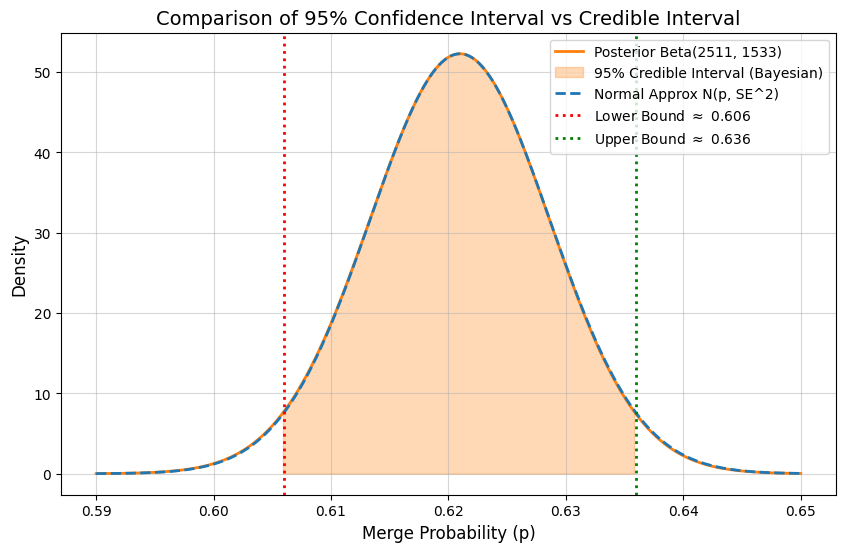

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, beta  # Tambahkan baris ini

fig, ax = plt.subplots(figsize=(10, 6))

# Range probabilitas p (fokus di sekitar puncak grafik)
p_values = np.linspace(0.59, 0.65, 1000)

# 1. Plot Bayesian Posterior & Arsiran CrI
posterior_pdf = beta.pdf(p_values, alpha_post, beta_post)
ax.plot(p_values, posterior_pdf, color='#ff7f0e', linewidth=2, label=f'Posterior Beta({alpha_post}, {beta_post})')

p_fill_bayes = np.linspace(bayes_cri['lower_bound'], bayes_cri['upper_bound'], 500)
ax.fill_between(p_fill_bayes, beta.pdf(p_fill_bayes, alpha_post, beta_post), 
                color='#ff7f0e', alpha=0.3, label='95% Credible Interval (Bayesian)')

# 2. Plot Frequentist Normal Approximation
se = np.sqrt((p_hat * (1 - p_hat)) / n_total)
normal_pdf = norm.pdf(p_values, p_hat, se)
ax.plot(p_values, normal_pdf, color='#1f77b4', linestyle='--', linewidth=2, label='Normal Approx N(p, SE^2)')

# Garis batas bawah dan atas
ax.axvline(freq_ci['lower_bound'], color='red', linestyle=':', linewidth=2, label=f"Lower Bound $\\approx$ {freq_ci['lower_bound']:.3f}")
ax.axvline(freq_ci['upper_bound'], color='green', linestyle=':', linewidth=2, label=f"Upper Bound $\\approx$ {freq_ci['upper_bound']:.3f}")

ax.set_title("Comparison of 95% Confidence Interval vs Credible Interval", fontsize=14)
ax.set_xlabel("Merge Probability (p)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.5)

plt.show()

### Analisis

Analisis ini bertujuan untuk mengukur tingkat ketidakpastian atau margin of error dari estimasi titik probabilitas keberhasilan sebuah pull request untuk digabungkan ke dalam repositori utama pandas-dev/pandas. Berdasarkan proses ekstraksi data pada tahap sebelumnya, kita memiliki sekumpulan observasi berdistribusi Bernoulli dengan total sampel sebanyak 4.042 pull request dan 2.510 di antaranya berhasil diterima (merged). Hal ini menghasilkan estimasi titik probabilitas sebesar 0.621 atau 62.1%. Mengingat ukuran sampel yang sangat besar, kita dapat melakukan estimasi interval dengan tingkat presisi dan keyakinan yang sangat tinggi melalui dua pendekatan filosofi statistik utama, yaitu Frequentist dan Bayesian.

Pendekatan Frequentist menggunakan aproksimasi Normal atau Wald Interval yang didasarkan pada prinsip Teorema Limit Pusat (Central Limit Theorem). Dengan menetapkan tingkat signifikansi sebesar 5%, perhitungan standar error dari data kita menghasilkan rentang Confidence Interval 95% pada interval 0.606 hingga 0.636. Interpretasi dari hasil ini adalah jika kita melakukan pengambilan sampel acak dengan ukuran yang sama dari repositori ini secara berulang-ulang hingga tak terhingga, maka 95% dari rentang interval yang terbentuk tersebut akan memuat nilai probabilitas keberhasilan merge yang sesungguhnya.

Di sisi lain, pendekatan Bayesian bekerja dengan cara menggabungkan keyakinan awal (prior) dengan probabilitas data aktual untuk membentuk distribusi yang diperbarui (Posterior). Proses ini dimulai dengan prior seragam Beta(1,1) yang bersifat tidak informatif. Prior tersebut kemudian diperbarui dengan fakta data observasi berupa 2.510 nilai sukses dan 1.532 nilai gagal, sehingga menghasilkan distribusi Posterior Beta(2511, 1533). Berdasarkan luasan area di bawah kurva distribusi Posterior tersebut (ditandai dengan arsiran pada grafik), terdapat tingkat probabilitas subjektif sebesar 95% bahwa nilai parameter probabilitas merge yang sebenarnya berada secara persis di dalam rentang 0.606 hingga 0.636.

Analisis visual dari grafik perbandingan antara Confidence Interval dan Credible Interval menunjukkan sebuah fenomena statistik yang sangat penting, yaitu terjadinya konvergensi model. Batas-batas interval dari pendekatan Frequentist terlihat berhimpit sejajar dengan batas interval dari pendekatan Bayesian. Kesamaan ini membuktikan bahwa ketika ukuran sampel observasi kita sangat melimpah, data secara mutlak mendominasi model dan membuat asumsi prior menjadi tidak lagi signifikan. Selain itu, kurva distribusi terlihat sangat ramping dan terpusat, mengindikasikan varians yang sangat kecil dengan margin ketidakpastian yang hanya berada di kisaran 1.5%. Sebagai kesimpulan akhir, kita dapat menyatakan dengan tingkat keyakinan 95% bahwa rasio keberhasilan merge pull request pada proyek ini secara stabil berada di kisaran 60.6% hingga 63.6%, yang mana angka presisi ini memberikan fondasi yang solid untuk tahap Pengujian Hipotesis selanjutnya.